In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from glob import glob
import os
from skimage import io

In [4]:
path = r'G:\My Drive\Ba Tagging\data\img\sets\08-05-25\Rhodamine-B 5 µM 270225'
glob(path + '/**/')

['G:\\My Drive\\Ba Tagging\\data\\img\\sets\\08-05-25\\Rhodamine-B 5 µM 270225\\01\\',
 'G:\\My Drive\\Ba Tagging\\data\\img\\sets\\08-05-25\\Rhodamine-B 5 µM 270225\\02\\',
 'G:\\My Drive\\Ba Tagging\\data\\img\\sets\\08-05-25\\Rhodamine-B 5 µM 270225\\03\\',
 'G:\\My Drive\\Ba Tagging\\data\\img\\sets\\08-05-25\\Rhodamine-B 5 µM 270225\\04\\']

In [69]:
path2DM = path + '\\01\\*.tif'
files2dm = sorted(glob(path2DM))

path3DM = path + '\\02\\*.tif'
files3dm = sorted(glob(path3DM))

In [74]:
for file in files2dm:
    if 'Dark' in file:
        img_bg = io.imread(file).astype(np.int16)

counts2dm = []
counts3dm = []
filt_centers = []
filt_widths = []
for file in files2dm:
    if 'Dark' not in file and 'NA' not in file:
        filename = os.path.basename(file)
        filt_center = filename.split('_')[0].split('-')[1].replace('nm', '')
        filt_width = filename.split('_')[1].split('-')[1].replace('nm', '')
        filt_centers.append(int(filt_center))
        filt_widths.append((filt_width))
        img = io.imread(file).astype(np.int16)
        img = img - img_bg
        counts2dm.append(np.sum(img))

for file in files3dm:
    if 'Dark' in file:
        img_bg = io.imread(file).astype(np.int16)

for file in files3dm:
    if 'Dark' not in file and 'NA' not in file:
        img = io.imread(file).astype(np.int16)
        img = img - img_bg
        counts3dm.append(np.sum(img))

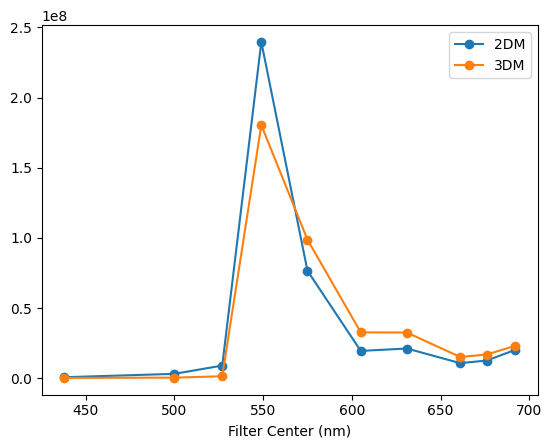

In [77]:
plt.plot(filt_centers, counts2dm, 'o-', label='2DM')
plt.plot(filt_centers, counts3dm, 'o-', label='3DM')
plt.xlabel('Filter Center (nm)')
plt.legend()